# Exploratory Data Analysis — Brain Tumour MRI

Before modelling, this notebook explores the two datasets used in the project:

1. **Medical Segmentation Decathlon — Task01_BrainTumour** (segmentation): multi-modal
   MRI + expert tumour masks.
2. **BraTS 2020** (survival): the same MRI family, plus clinical labels
   (overall survival, age, resection).

We look at image properties, intensity distributions (*why* we normalise), the
severe class imbalance, tumour-size distributions, and how tumour features relate
to survival.

In [1]:
import glob, json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, nibabel as nib
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")
rng = np.random.default_rng(0)

DEC = "data/Task01_BrainTumour"
BRATS = "data/brats2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
MODS = ["FLAIR", "T1w", "T1gd", "T2w"]
# Decathlon label map: 1=edema, 2=non-enhancing, 3=enhancing
REGION = {"TC (core)": lambda s: (s==2)|(s==3),
          "WT (whole)": lambda s: (s==1)|(s==2)|(s==3),
          "ET (enhancing)": lambda s: s==3}
def files(sub):  # drop macOS ._ sidecar files
    return sorted(f for f in glob.glob(f"{DEC}/{sub}/*.nii.gz") if "/._" not in f)
print("ready")

ready


## 1. Dataset overview

In [2]:
dj = json.load(open(f"{DEC}/dataset.json"))
imgs, lbls = files("imagesTr"), files("labelsTr")
surv = pd.read_csv(f"{BRATS}/survival_info.csv")
print("Decathlon Task01 —", dj.get("name"))
print(f"  labelled training volumes : {len(imgs)}")
print(f"  modalities                : {dj['modality']}")
print(f"  labels                    : {dj['labels']}")
print(f"\nBraTS 2020 survival records : {len(surv)}")
print("  columns                   :", list(surv.columns))

Decathlon Task01 — BRATS
  labelled training volumes : 484
  modalities                : {'0': 'FLAIR', '1': 'T1w', '2': 't1gd', '3': 'T2w'}
  labels                    : {'0': 'background', '1': 'edema', '2': 'non-enhancing tumor', '3': 'enhancing tumour'}

BraTS 2020 survival records : 236
  columns                   : ['Brats20ID', 'Age', 'Survival_days', 'Extent_of_Resection']


## 2. Segmentation dataset — image properties

Each case is a **4-D volume**: three spatial dimensions × four MRI modalities.

In [3]:
shapes, spacings = [], []
for f in imgs[:30]:
    h = nib.load(f)
    shapes.append(h.shape); spacings.append(h.header.get_zooms()[:3])
shp = pd.DataFrame(shapes, columns=["X","Y","Z","modalities"])
print("Volume shape (first 30 cases):")
print(shp.describe().loc[["min","max","mean"]].round(1))
print("\nVoxel spacing (mm):", np.round(np.mean(spacings,0),2), "— isotropic 1mm, all modalities co-registered")

Volume shape (first 30 cases):
          X      Y      Z  modalities
min   240.0  240.0  155.0         4.0
max   240.0  240.0  155.0         4.0
mean  240.0  240.0  155.0         4.0

Voxel spacing (mm): [1. 1. 1.] — isotropic 1mm, all modalities co-registered


### 2.1 What the four modalities look like
Each modality highlights tissue differently — the tumour is most conspicuous on FLAIR/T2.

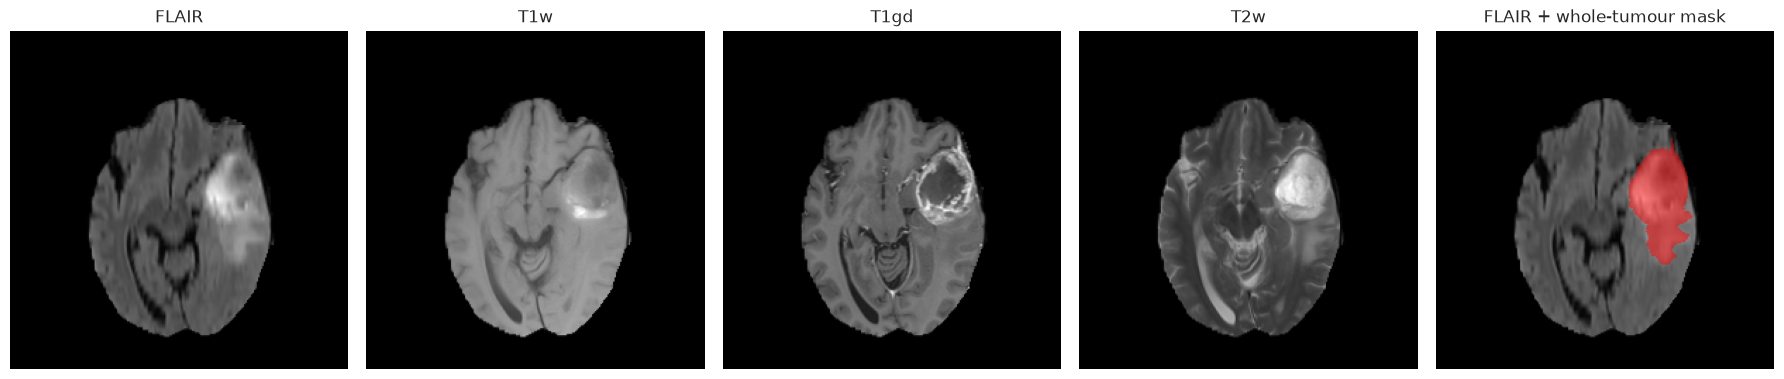

In [4]:
def load_case(i):
    img = np.asarray(nib.load(imgs[i]).dataobj)      # (X,Y,Z,4)
    lbl = np.asarray(nib.load(lbls[i]).dataobj)      # (X,Y,Z)
    return img, lbl
img, lbl = load_case(0)
wt = REGION["WT (whole)"](lbl)
z = int(wt.sum((0,1)).argmax())
fig, ax = plt.subplots(1, 5, figsize=(18,4))
for c in range(4):
    ax[c].imshow(np.rot90(img[:,:,z,c]), cmap="gray"); ax[c].set_title(MODS[c]); ax[c].axis("off")
ax[4].imshow(np.rot90(img[:,:,z,0]), cmap="gray")
wts = np.rot90(wt[:,:,z])
ax[4].imshow(np.ma.masked_where(wts==0, wts), cmap="autumn", alpha=.5)
ax[4].set_title("FLAIR + whole-tumour mask"); ax[4].axis("off")
plt.tight_layout(); plt.show()

### 2.2 Intensity distributions — *why we normalise*

MRI intensities are **not standardised** across scanners: the same tissue can map to
very different raw values. The histograms below (non-zero voxels, sampled cases) show
each modality on a different scale — motivating the per-channel z-score normalisation
used in the pipeline.

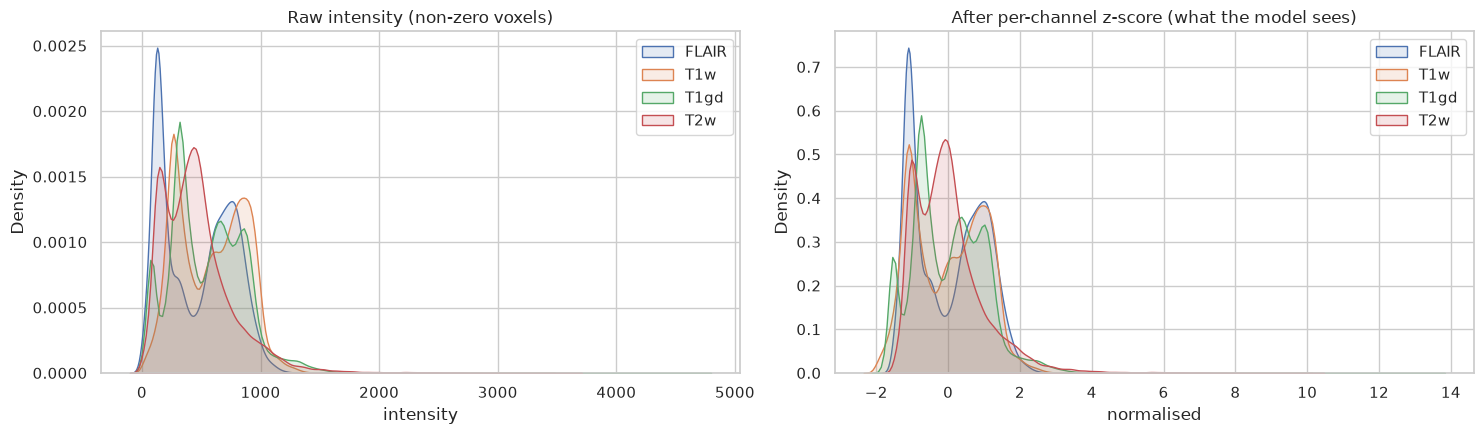

In [5]:
samples = {m: [] for m in MODS}
for f in rng.choice(imgs, 15, replace=False):
    v = np.asarray(nib.load(f).dataobj)
    for c,m in enumerate(MODS):
        vals = v[...,c][v[...,c] > 0]
        samples[m].append(rng.choice(vals, min(4000, vals.size), replace=False))
fig, ax = plt.subplots(1, 2, figsize=(15,4.5))
for m in MODS:
    sns.kdeplot(np.concatenate(samples[m]), ax=ax[0], label=m, fill=True, alpha=.15)
ax[0].set_title("Raw intensity (non-zero voxels)"); ax[0].set_xlabel("intensity"); ax[0].legend()
for m in MODS:
    d = np.concatenate(samples[m]); z = (d-d.mean())/d.std()
    sns.kdeplot(z, ax=ax[1], label=m, fill=True, alpha=.15)
ax[1].set_title("After per-channel z-score (what the model sees)"); ax[1].set_xlabel("normalised"); ax[1].legend()
plt.tight_layout(); plt.show()

## 3. Tumour labels — class imbalance & region sizes

The defining challenge of medical segmentation: tumour is a **tiny fraction** of the
volume. This is why Dice Loss (not cross-entropy) is used.

> **Label convention note.** Decathlon Task01 uses `1=edema, 2=non-enhancing, 3=enhancing`
> — *different* from the original BraTS `1/2/4` convention. Using the wrong mapping
> silently produces an empty enhancing-tumour channel (a bug caught during Phase 2).

In [6]:
rows = []
for f in rng.choice(lbls, 80, replace=False):
    s = np.asarray(nib.load(f).dataobj)
    brain = (s >= 0).size  # full volume
    tumour = (s > 0).sum()
    r = {"foreground_%": 100*tumour/brain}
    for name, fn in REGION.items():
        r[name] = int(fn(s).sum())/1000.0   # cm^3 (1mm iso)
    rows.append(r)
vol = pd.DataFrame(rows)
print("Tumour as % of full volume:")
print(vol["foreground_%"].describe()[["mean","50%","max"]].round(2).to_string())
print(f"\n=> on average only ~{vol['foreground_%'].mean():.1f}% of voxels are tumour — severe imbalance.")

Tumour as % of full volume:
mean    1.18
50%     1.08
max     2.99

=> on average only ~1.2% of voxels are tumour — severe imbalance.


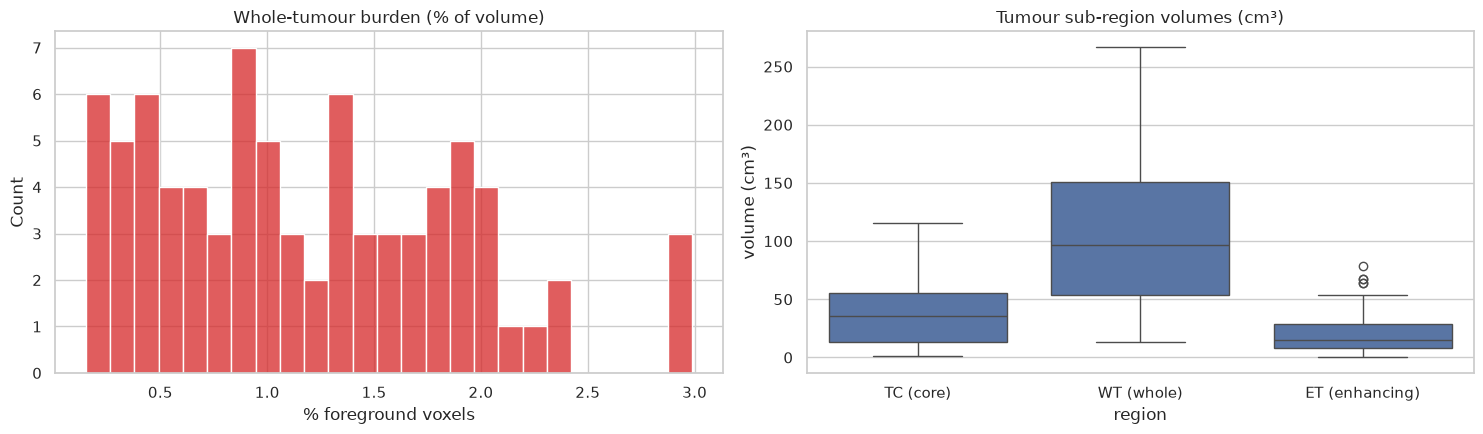

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15,4.5))
sns.histplot(vol["foreground_%"], bins=25, ax=ax[0], color="#d62728")
ax[0].set_title("Whole-tumour burden (% of volume)"); ax[0].set_xlabel("% foreground voxels")
melt = vol[list(REGION)].melt(var_name="region", value_name="cm3")
sns.boxplot(data=melt, x="region", y="cm3", ax=ax[1])
ax[1].set_title("Tumour sub-region volumes (cm³)"); ax[1].set_ylabel("volume (cm³)")
plt.tight_layout(); plt.show()

## 4. Understanding the inputs and targets

Before modelling, it helps to see *what goes into* the model (four MRI modalities) and
*what comes out* (three tumour regions).

### The four MRI modalities — why we need all four
Each modality is a different MRI "recipe" that makes different tissue bright, so no
single scan tells the whole story:

| Modality | What lights up | Reveals |
|---|---|---|
| **FLAIR** | edema + tumour (brain fluid darkened) | whole-tumour extent |
| **T2** | edema + tumour | whole-tumour extent |
| **T1ce** (contrast) | actively-growing (*enhancing*) tumour | enhancing tumour + core |
| **T1** | plain anatomy | baseline for comparison |

Below: one case — top row = the four modalities; bottom row = each tumour region drawn
on the scan that reveals it best.

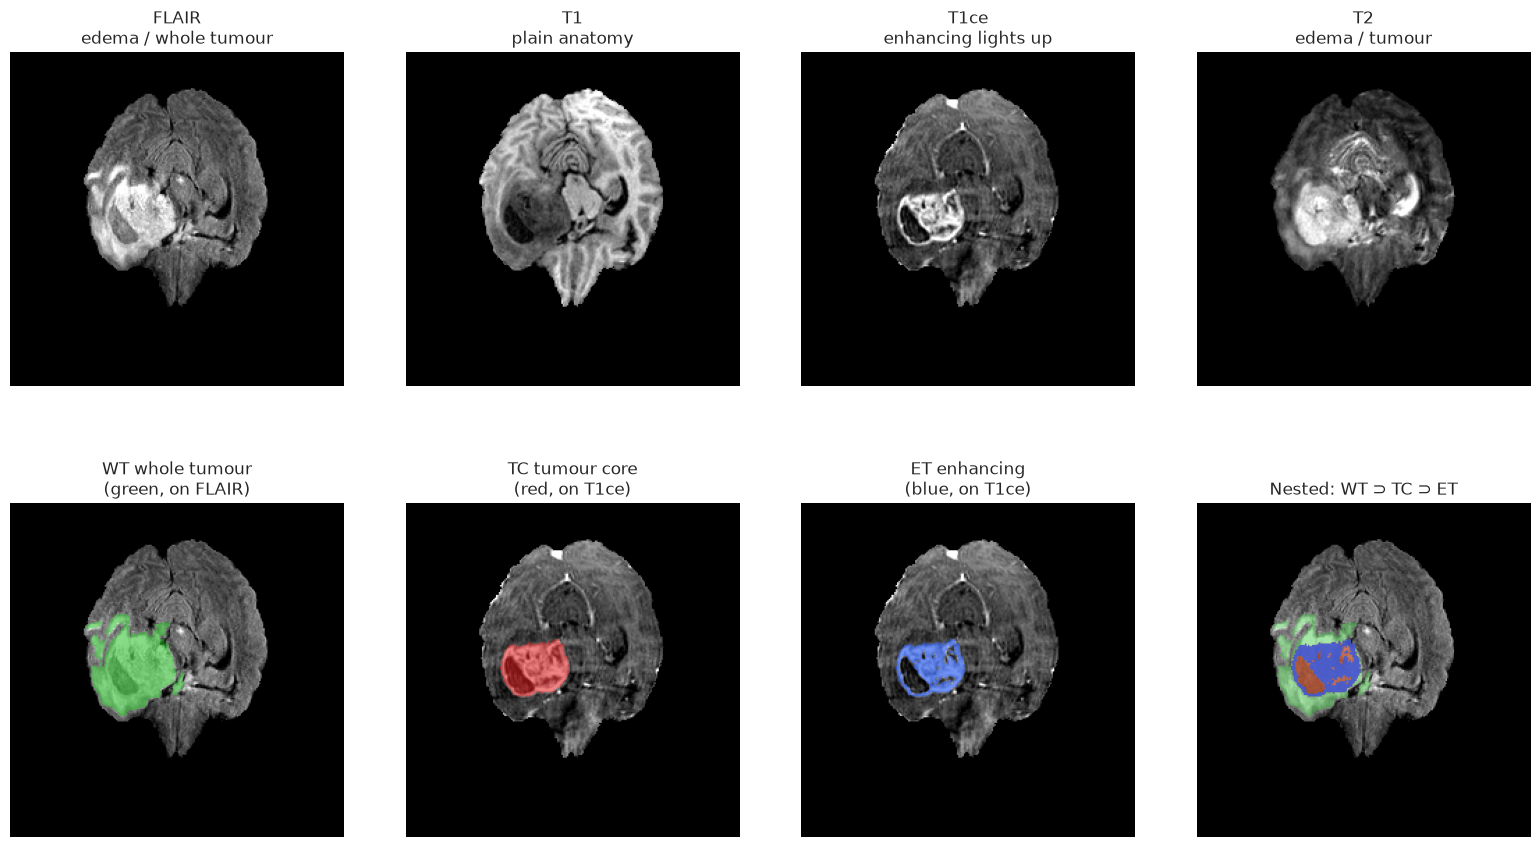

In [8]:
# One case: 4 modalities, then each region on the scan that reveals it best
pid = "BraTS20_Training_001"; cf = f"{BRATS}/{pid}"
M = {m: np.asarray(nib.load(f"{cf}/{pid}_{m}.nii").dataobj) for m in ["flair","t1","t1ce","t2"]}
seg = np.asarray(nib.load(f"{cf}/{pid}_seg.nii").dataobj)          # BraTS labels 1/2/4
wt=(seg==1)|(seg==2)|(seg==4); tc=(seg==1)|(seg==4); et=(seg==4)   # regions
z=int(et.sum((0,1)).argmax())
S=lambda a: np.rot90(a[:,:,z])
def g(ax,img):
    b=S(img); v=b[b>0]; ax.imshow(b,cmap="gray",vmin=np.percentile(v,1),vmax=np.percentile(v,99)); ax.axis("off")
def ov(ax,mask,rgb,al=.55):
    m=S(mask); o=np.zeros((*m.shape,4)); o[m]=[*rgb,al]; ax.imshow(o)
GR,RD,BL=(.15,.75,.15),(.9,.12,.12),(.15,.35,.95)
fig,ax=plt.subplots(2,4,figsize=(16,8.5))
for c,(m,t,s) in enumerate([("flair","FLAIR","edema / whole tumour"),("t1","T1","plain anatomy"),
                            ("t1ce","T1ce","enhancing lights up"),("t2","T2","edema / tumour")]):
    g(ax[0,c],M[m]); ax[0,c].set_title(f"{t}\n{s}")
g(ax[1,0],M["flair"]); ov(ax[1,0],wt,GR); ax[1,0].set_title("WT whole tumour\n(green, on FLAIR)")
g(ax[1,1],M["t1ce"]);  ov(ax[1,1],tc,RD); ax[1,1].set_title("TC tumour core\n(red, on T1ce)")
g(ax[1,2],M["t1ce"]);  ov(ax[1,2],et,BL,.65); ax[1,2].set_title("ET enhancing\n(blue, on T1ce)")
g(ax[1,3],M["flair"]); ov(ax[1,3],wt,GR,.4); ov(ax[1,3],tc,RD,.55); ov(ax[1,3],et,BL,.75)
ax[1,3].set_title("Nested: WT \u2283 TC \u2283 ET")
plt.tight_layout(); plt.subplots_adjust(hspace=0.35); plt.show()

### The three tumour regions: TC / WT / ET
The expert labels three tissue types — **edema** (swelling), **non-enhancing / necrotic
core** (dead centre), and **enhancing tumour** (active rim). The model predicts three
*overlapping* regions built from them:

| Region | = tissues | Clinical meaning |
|---|---|---|
| **ET** — Enhancing Tumour | enhancing | active, aggressive disease |
| **TC** — Tumour Core | necrotic + enhancing | the solid mass a surgeon removes |
| **WT** — Whole Tumour | edema + necrotic + enhancing | total extent of abnormality |

They **nest**: `ET ⊆ TC ⊆ WT`. In the figure above, note that TC (red) is a *filled*
blob while ET (blue) is a *ring* — the dark hole is the necrotic core, which belongs to
the core but is not "enhancing".

### How the data feeds the model
- **Input (image):** the four modalities stacked as channels → shape `(4, 240, 240, 155)`.
- **Target (label):** one volume of integer labels 0/1/2/3, converted into three binary
  masks (TC, WT, ET) → shape `(3, 240, 240, 155)`.
- **Prediction is a mask:** the model outputs a per-voxel probability for each region,
  then thresholds at 0.5 into a **binary mask** — a 3-D stencil marking every voxel as
  tumour or not. Tumour *volume* is simply the count of 1-voxels.
- **Training:** `in_channels=4, out_channels=3`; each region uses an independent
  **sigmoid** (the regions overlap, so *not* softmax), and **Dice Loss** is scored per
  region — which is why accuracy is always reported as TC / WT / ET separately.

## 5. Survival dataset (BraTS 2020)

The 3-class survival task follows the BraTS challenge cutoffs:
**short** < 300 d (<10 mo), **mid** 300–450 d (10–15 mo), **long** > 450 d (>15 mo).

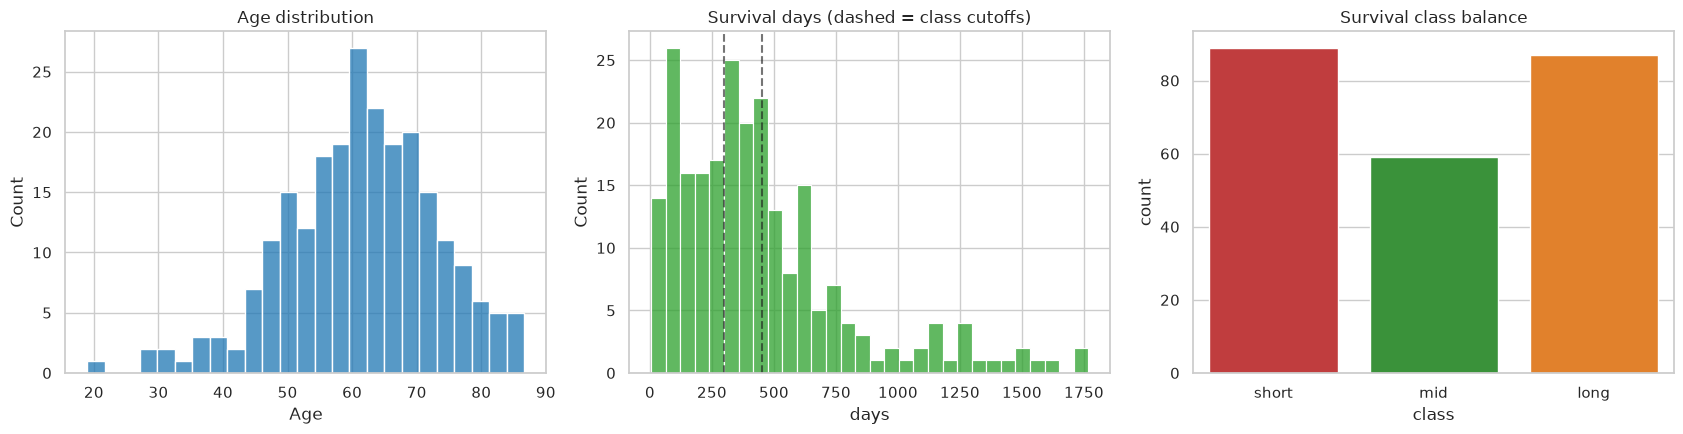

Resection status:
 Extent_of_Resection
GTR    119
NaN    107
STR     10


In [9]:
s = surv.copy()
s["days"] = pd.to_numeric(s["Survival_days"], errors="coerce")
s = s.dropna(subset=["days"])
def cls(d): return "short" if d<300 else ("mid" if d<=450 else "long")
s["class"] = s["days"].map(cls)
fig, ax = plt.subplots(1, 3, figsize=(17,4.5))
sns.histplot(s["Age"], bins=25, ax=ax[0], color="#1f77b4"); ax[0].set_title("Age distribution")
sns.histplot(s["days"], bins=30, ax=ax[1], color="#2ca02c")
for c in (300,450): ax[1].axvline(c, ls="--", c="k", alpha=.6)
ax[1].set_title("Survival days (dashed = class cutoffs)"); ax[1].set_xlabel("days")
order = ["short","mid","long"]
sns.countplot(x="class", data=s, order=order, ax=ax[2], hue="class", palette=["#d62728","#ff7f0e","#2ca02c"], legend=False)
ax[2].set_title("Survival class balance")
plt.tight_layout(); plt.show()
print("Resection status:\n", surv["Extent_of_Resection"].value_counts(dropna=False).to_string())

## 6. Tumour features vs survival

Using the extracted feature table (`survival_features.csv`), do tumour characteristics
actually relate to survival? We look at feature distributions by class and correlations
with survival time.

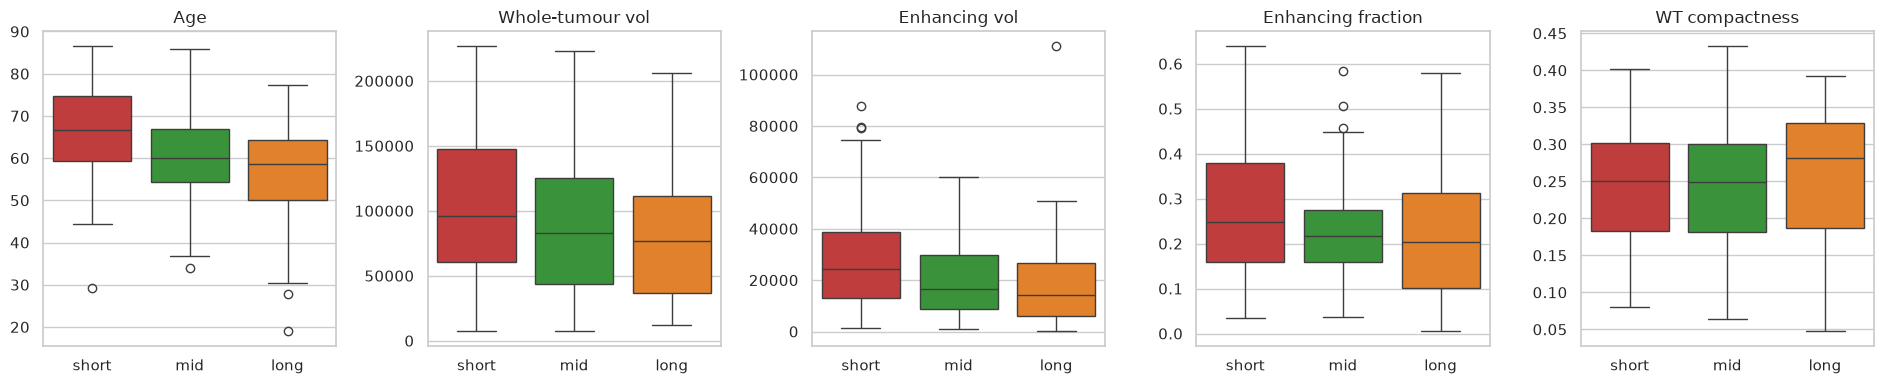

In [10]:
feat = pd.read_csv("survival_features.csv").dropna(subset=["survival_class"])
feat["class"] = feat["survival_class"].map({0:"short",1:"mid",2:"long"})
key = ["age","gt_vol_wt","gt_vol_et","gt_ratio_et_wt","gt_wt_compactness"]
titles = ["Age","Whole-tumour vol","Enhancing vol","Enhancing fraction","WT compactness"]
fig, ax = plt.subplots(1, len(key), figsize=(19,4))
for a,k,t in zip(ax,key,titles):
    sns.boxplot(data=feat, x="class", y=k, order=["short","mid","long"], ax=a,
                hue="class", palette=["#d62728","#ff7f0e","#2ca02c"], legend=False)
    a.set_title(t); a.set_xlabel(""); a.set_ylabel("")
plt.tight_layout(); plt.show()

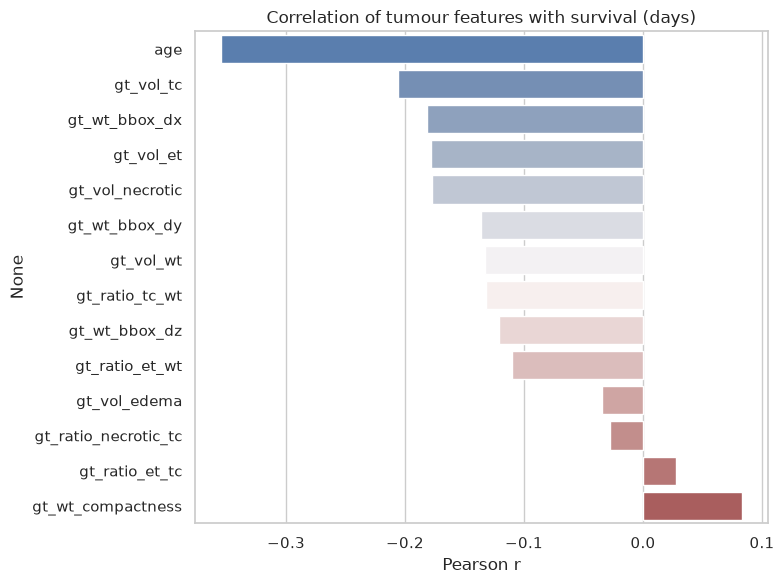

In [11]:
# correlation of features with survival days (expert-mask features)
fcols = [c for c in feat.columns if c.startswith("gt_")] + ["age"]
corr = feat[fcols + ["survival_days"]].corr()["survival_days"].drop("survival_days").sort_values()
plt.figure(figsize=(8,6))
sns.barplot(x=corr.values, y=corr.index, hue=corr.index, palette="vlag", legend=False)
plt.title("Correlation of tumour features with survival (days)"); plt.xlabel("Pearson r")
plt.tight_layout(); plt.show()

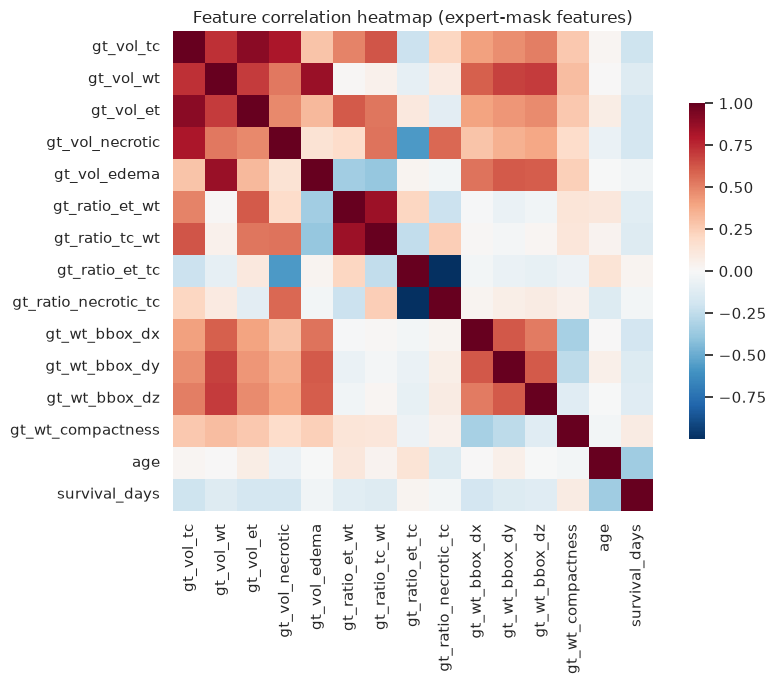

In [12]:
# feature correlation structure
plt.figure(figsize=(9,7))
cc = feat[[c for c in feat.columns if c.startswith("gt_")]+["age","survival_days"]].corr()
sns.heatmap(cc, cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink":.7})
plt.title("Feature correlation heatmap (expert-mask features)")
plt.tight_layout(); plt.show()

## 7. Key takeaways

- **4-D multi-modal input** — four co-registered 1 mm MRI modalities per case; the
  tumour is most visible on FLAIR/T2.
- **Intensities are not standardised** across scanners → per-channel z-score
  normalisation is essential before training.
- **Severe class imbalance** — tumour is only a few percent of each volume, which is
  why **Dice Loss** is used instead of cross-entropy.
- **Label convention matters** — Decathlon's `1/2/3` labels differ from BraTS `1/2/4`;
  the wrong mapping silently breaks the enhancing-tumour channel.
- **Survival signal is real but modest** — larger tumours, higher enhancing fraction,
  and older age trend toward shorter survival, but the relationships are noisy
  (consistent with the modest AUCs and the known difficulty of the task).